<a href="https://colab.research.google.com/github/reinan-silvaa/INTELIGENCIA-ARTIFICIAl/blob/main/C%C3%B3pia_de_Atividade_Benedito_Reinan_Matutino_6D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação Das Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)

# Carregando o dataset Iris

In [2]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species_id")

species_names = {i: name for i, name in enumerate(iris.target_names)}

df = X.copy()
df["species_id"] = y
df["species"] = df["species_id"].map(species_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Conhecendo a estrutura dos dados

In [3]:
print("Dimensão do dataset:", df.shape)
print("\nNomes das colunas:")
for col in df.columns:
    print("-", col)

print("\nContagem por espécie:")
print(df["species"].value_counts())

Dimensão do dataset: (150, 6)

Nomes das colunas:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)
- species_id
- species

Contagem por espécie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Exploração visual

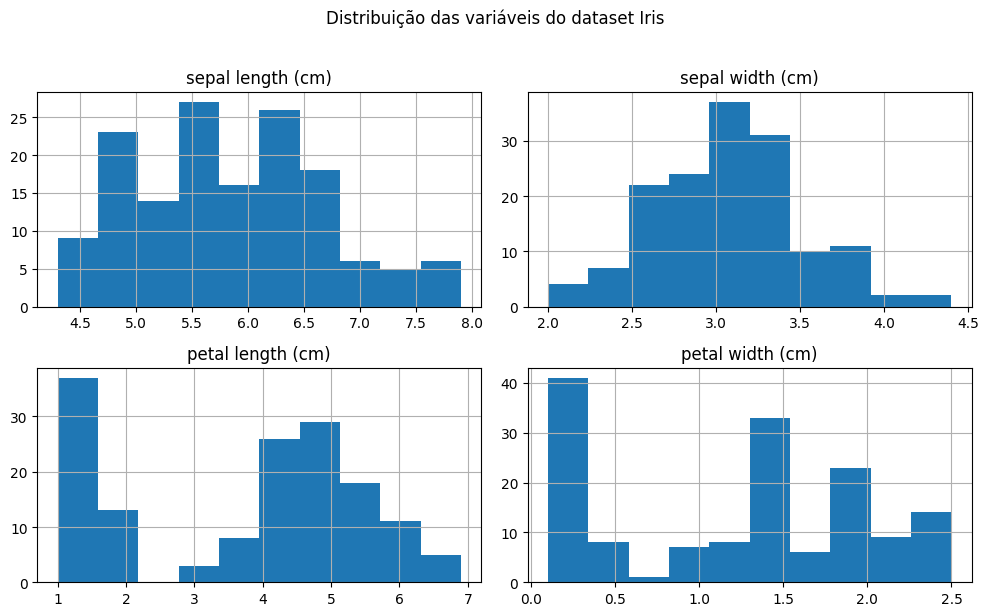

In [5]:
df[X.columns].hist(figsize=(10, 6))
plt.suptitle("Distribuição das variáveis do dataset Iris", y=1.02)
plt.tight_layout()
plt.show()

# Definindo entradas e saída

In [6]:
X = df[iris.feature_names]
y = df["species"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (150, 4)
Formato de y: (150,)


# Dividindo os dados em treino e teste

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

X_train: (120, 4)
X_test : (30, 4)

Distribuição em y_train:
species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

Distribuição em y_test:
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


# Padronização dos dados
Experimento 1 — SVM linear

In [8]:
pipeline_svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=42))
])

pipeline_svm_linear.fit(X_train, y_train)

y_pred_linear = pipeline_svm_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM linear: {acc_linear:.4f}")

Acurácia do SVM linear: 1.0000


In [9]:
print("Relatório de classificação — SVM linear\n")
print(classification_report(y_test, y_pred_linear))

Relatório de classificação — SVM linear

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



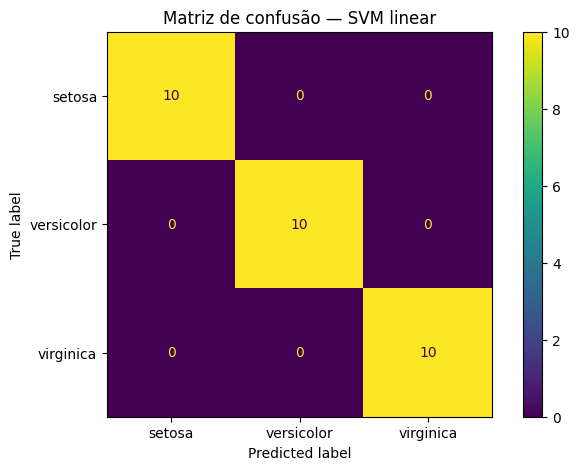

In [10]:
cm_linear = confusion_matrix(y_test, y_pred_linear, labels=iris.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=iris.target_names)
disp.plot()
plt.title("Matriz de confusão — SVM linear")
plt.show()

# Validação cruzada do SVM linear

In [11]:
scores_linear = cross_val_score(pipeline_svm_linear, X, y, cv=5)

print("Acurácia em cada fold:", scores_linear)
print(f"Média: {scores_linear.mean():.4f}")
print(f"Desvio-padrão: {scores_linear.std():.4f}")

Acurácia em cada fold: [0.96666667 1.         0.93333333 0.93333333 1.        ]
Média: 0.9667
Desvio-padrão: 0.0298


# Experimento 2 — SVM não linear com kernel RBF

In [12]:
pipeline_svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipeline_svm_rbf.fit(X_train, y_train)

y_pred_rbf = pipeline_svm_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM com kernel RBF: {acc_rbf:.4f}")

Acurácia do SVM com kernel RBF: 0.9667


In [13]:
print("Relatório de classificação — SVM com kernel RBF\n")
print(classification_report(y_test, y_pred_rbf))

Relatório de classificação — SVM com kernel RBF

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



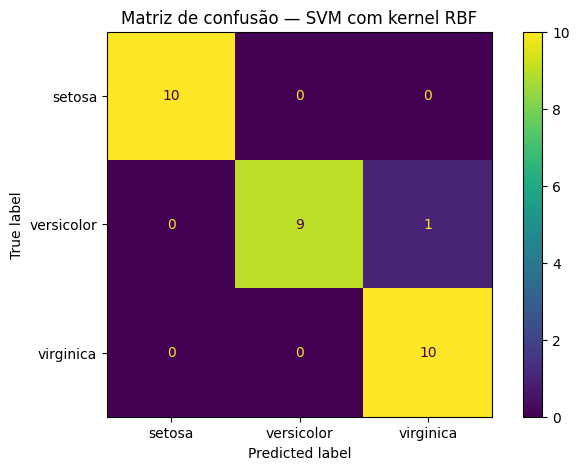

In [14]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=iris.target_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=iris.target_names)
disp.plot()
plt.title("Matriz de confusão — SVM com kernel RBF")
plt.show()

# Validação cruzada do SVM com kernel RBF

In [15]:
scores_rbf = cross_val_score(pipeline_svm_rbf, X, y, cv=5)

print("Acurácia em cada fold:", scores_rbf)
print(f"Média: {scores_rbf.mean():.4f}")
print(f"Desvio-padrão: {scores_rbf.std():.4f}")

Acurácia em cada fold: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Média: 0.9667
Desvio-padrão: 0.0211


# Comparação entre os modelos

In [16]:
comparacao = pd.DataFrame({
    "Modelo": ["SVM linear", "SVM não linear (RBF)"],
    "Acurácia no teste": [acc_linear, acc_rbf],
    "Acurácia média CV": [scores_linear.mean(), scores_rbf.mean()],
    "Desvio-padrão CV": [scores_linear.std(), scores_rbf.std()]
})

comparacao

,Modelo,Acurácia no teste,Acurácia média CV,Desvio-padrão CV
0,SVM linear,1.000000,0.966667,0.029814
1,SVM não linear (RBF),0.966667,0.966667,0.021082


# EXERCÍCIO PRÁTICO 1

Criando um modelo SVM com kernel polinomial

Neste primeiro teste, utilizei o SVM com kernel polinomial. Mantive o valor de C em 1 e utilizei grau 3 para o polinômio. Primeiro o modelo faz a padronização dos dados e depois realiza o treinamento. No final, usei os dados de teste para verificar a acurácia do modelo.


In [17]:
# EXERCÍCIO PRÁTICO 1
# Criando um modelo SVM com kernel polinomial

pipeline_svm_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="poly",
        degree=3,
        C=1.0,
        gamma="scale",
        random_state=42
    ))
])

# Treinando o modelo
pipeline_svm_poly.fit(X_train, y_train)

# Fazendo as previsões
y_pred_poly = pipeline_svm_poly.predict(X_test)

# Calculando a acurácia
acc_poly = accuracy_score(y_test, y_pred_poly)

print(f"Acurácia do SVM polinomial: {acc_poly:.4f}")

Acurácia do SVM polinomial: 0.9000


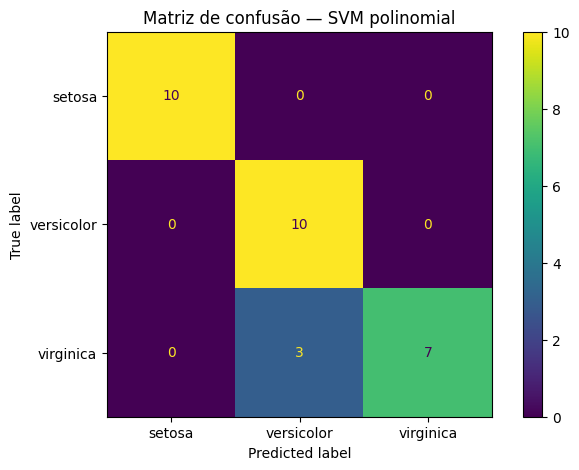

In [18]:
# Criando a matriz de confusão
cm_poly = confusion_matrix(
    y_test,
    y_pred_poly,
    labels=y.unique()
)

# Exibindo a matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_poly,
    display_labels=y.unique()
)

disp.plot()
plt.title("Matriz de confusão — SVM polinomial")
plt.show()


# EXERCÍCIO PRÁTICO 2

Testando diferentes valores de C no SVM com kernel RBF

Neste teste, alterei somente o valor do parâmetro C do SVM com kernel RBF. Fiz isso para observar se o desempenho do modelo muda quando o parâmetro recebe valores menores ou maiores. Depois comparei as acurácias obtidas para identificar qual configuração apresentou o melhor resultado.

In [19]:
# EXERCÍCIO PRÁTICO 2
# Testando diferentes valores de C no SVM com kernel RBF

valores_c = [0.1, 1, 10, 100]

for valor in valores_c:

    # Cria o modelo com o valor de C escolhido
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=valor,
            gamma="scale",
            random_state=42
        ))
    ])

    # Treina o modelo
    modelo.fit(X_train, y_train)

    # Faz as previsões
    previsoes = modelo.predict(X_test)

    # Calcula a acurácia
    acuracia = accuracy_score(y_test, previsoes)

    print(f"C = {valor} → Acurácia: {acuracia:.4f}")


C = 0.1 → Acurácia: 0.9000
C = 1 → Acurácia: 0.9667
C = 10 → Acurácia: 0.9667
C = 100 → Acurácia: 0.9667


# EXERCÍCIO PRÁTICO 3

Testando diferentes valores de gamma no SVM com kernel RBF

Neste último teste, mantive o C igual a 1 e alterei o valor de gamma. O objetivo foi observar como diferentes configurações do kernel RBF influenciam o resultado do modelo. Depois de executar os testes, comparei as acurácias para verificar qual configuração apresentou o melhor desempenho.


In [20]:
# EXERCÍCIO PRÁTICO 3
# Testando diferentes valores de gamma no SVM com kernel RBF

valores_gamma = ["scale", "auto", 0.1, 1]

for valor in valores_gamma:

    # Cria o modelo com o gamma escolhido
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1.0,
            gamma=valor,
            random_state=42
        ))
    ])

    # Treina o modelo
    modelo.fit(X_train, y_train)

    # Faz as previsões
    previsoes = modelo.predict(X_test)

    # Calcula a acurácia
    acuracia = accuracy_score(y_test, previsoes)

    print(f"gamma = {valor} → Acurácia: {acuracia:.4f}")


gamma = scale → Acurácia: 0.9667
gamma = auto → Acurácia: 0.9667
gamma = 0.1 → Acurácia: 0.9667
gamma = 1 → Acurácia: 0.9333


# Questões

**1. O que é classificação supervisionada?**
Resposta:
É quando o modelo aprende através de exemplos que já possuem uma resposta correta. Depois desse aprendizado, ele tenta classificar novos dados sozinho.

**2. Quais são as entradas e a saída no Iris?**
Resposta:
As entradas são as medidas de comprimento e largura da sépala e da pétala. A saída é a espécie da flor: setosa, versicolor ou virginica.

**3. Qual é a ideia principal do SVM?**^
Resposta:
O SVM tenta encontrar a melhor divisão entre as classes. Ele busca criar uma separação que deixe os grupos o mais bem separados possível.

**4. O que são vetores de suporte?**
Resposta:
São os pontos que ficam mais próximos da divisão entre as classes. Eles são importantes porque ajudam o SVM a definir onde essa divisão deve ficar.

**5. Qual a diferença entre SVM linear e não linear?**
Resposta:
O linear funciona melhor quando os dados podem ser separados de forma mais simples. O não linear consegue trabalhar com dados que possuem separações mais complexas.

**6. Por que padronizar os dados?**
Resposta:
Porque as características podem ter escalas diferentes. A padronização deixa os valores em escalas semelhantes e ajuda o SVM a trabalhar melhor.

**7. Para que serve o parâmetro C?**
Resposta:
O C controla o quanto o modelo tenta evitar erros. Um valor alto faz o modelo tentar acertar mais os dados de treino, enquanto um valor menor aceita mais erros.

**8. Para que serve o gamma?**
Resposta:
O gamma controla a influência que cada ponto tem no modelo. Dependendo do valor, a separação entre as classes pode ficar mais simples ou mais detalhada.

**9. O SVM linear teve um bom resultado?**
Resposta:
Sim. No teste realizado, ele conseguiu 100% de acurácia, ou seja, classificou corretamente todas as amostras do conjunto de teste.

**10. O RBF foi melhor que o linear?**
Resposta:
Não. O modelo linear conseguiu 100% de acerto, enquanto o RBF ficou com aproximadamente 96,67%. Nesse teste, o linear foi melhor.

**11. Quais espécies tiveram mais confusão?**
Resposta:
A maior confusão aconteceu entre versicolor e virginica. Isso ocorre porque essas duas espécies possuem características mais parecidas.

**12. Para que serve a validação cruzada?**
Resposta:
Ela serve para testar o modelo usando diferentes divisões dos dados. Assim, conseguimos ter mais confiança de que o resultado não aconteceu apenas por sorte.

**13. Por que escolher um modelo mais simples?**
Resposta:
Se dois modelos apresentam resultados parecidos, normalmente é melhor escolher o mais simples. Ele tende a ser mais fácil de entender e utilizar.

**14. O que aconteceu com o kernel polinomial?**
Resposta:
O kernel polinomial teve um resultado inferior aos outros modelos. Ele conseguiu aproximadamente 90% de acurácia no conjunto de teste.

**15. Qual valor de C pareceu melhor?**
Resposta:
O C=10 apresentou um resultado muito bom na validação cruzada. Porém, C=1 também teve um desempenho bem próximo.

**16. Mudar o gamma alterou muito o resultado?**
Resposta:
Não mudou muito na maioria dos testes. Alguns valores ficaram próximos de 96,67%, enquanto valores menos adequados diminuíram um pouco a acurácia.

**17. Quando usar um kernel não linear?**
Resposta:
Quando os dados possuem uma separação mais complexa e um modelo linear não consegue separar bem as classes. Nesse caso, kernels como o RBF podem ajudar.

**18. Quais são as vantagens e limitações do Iris?**
Resposta:
O Iris é bom para aprender porque é pequeno, organizado e fácil de entender. Porém, problemas reais normalmente possuem muito mais dados, erros, informações faltando e situações mais complexas.
